<a href="{{ colab_base_laboratorios }}/Laboratorio_08_clasificacionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 8: Clasificacion Logística 

Si deseamos clasificar algún tipo de imagen, resultado en campos medicos, astrofisicos se pueden aplicar algoritmos de clasificación. En particular en esta sesión se estudia los principios basicos de  regresión logística para aplicarla a los  modelos de clasificación. 

Supongamos que queremos clasificar un sistema que tiene dos tipos posibles (los llamaremos los tipos 0 y 1) basado en dos características (correspondiente a dos variables X1 y X2) :



In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification,make_circles
import numpy as np

Text(0, 0.5, 'X_2')

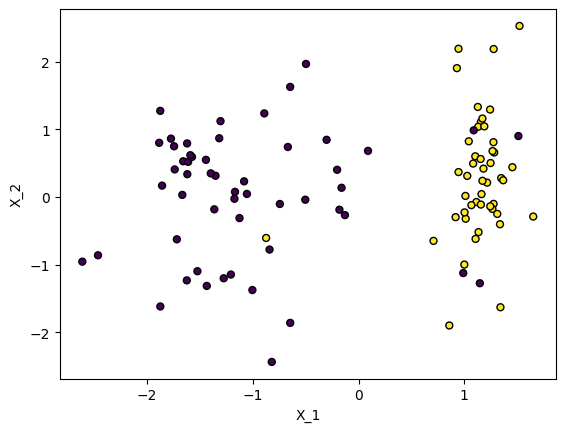

In [22]:
#Vamos a crear los datos de dos tipos introduciendo un porcentaje de
#valores con "ruido" (flip_y). Pruebe a cambiar el valor
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.xlabel("X_1")
plt.ylabel("X_2")

En este caso cada color representa los objetos tipos 0 y tipo 1. Para aplicar un algoritmo de clasificación relacionaremos el valor $h_{\theta}(X^{i}=x)$ con la probabilidad de obtener un valor de y dado un x parametrizado por $\theta$, $P(y=1|X=x;\theta)$, asi : 

 $h_{\theta}(X^{i}=x) = P(y=1|X^{i};\theta) $ 

 Tenemos que:  $P(y=1|x;\theta)+P(y=0|x;\theta) = 1$

Si tenemos muestra equiprobables, podemos definir lo siguiente  para P :

- $P<0.5$ se obtienen los objetos tipo 0 
- $P \geq 0.5$ se obtienen los objetos tipo 1

Podemos establecer un clasificador de los  sistemas basado en las probabilidades a partir de un clasificador logístico:


\begin{equation}
f(z)=\frac{1}{(1+e^{-z})}
\end{equation}
Cuya derivada es :

\begin{equation}
f'(z)=f(z)(1-f(z))
\end{equation}



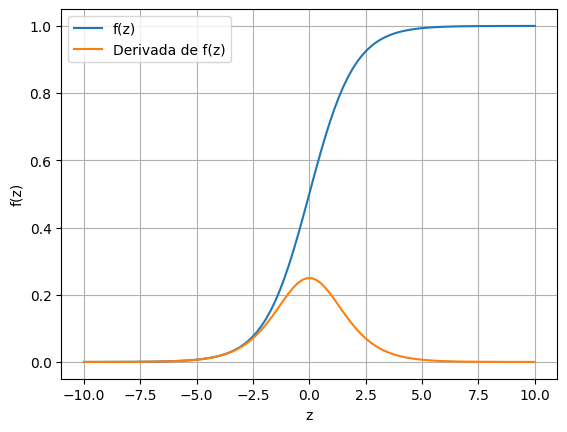

In [23]:
f = lambda x: 1/(1+np.exp(-x))
fp = lambda x: f(x)*(1-f(x))
z=np.linspace(-10, 10, 100)

plt.figure()
plt.plot(z,f(z), label="f(z)")
plt.plot(z,fp(z), label="Derivada de f(z)")
plt.ylabel("f(z)")
plt.xlabel("z")
plt.grid()
plt.legend()

- Para valores de $z< 0.0$ la regresión logistica clasica objetos tipo 0, siendo $f(z)<0.5$
- Para valores de $z\geq 0.0$ la regresión logística clasica objetos tipo 1 siendo $f(z) \geq  0.5$

¿Cual es la probabilidad de que dado un hyperplano, los valores de un hyperlado sean objetos tipo 0 o tipo 1?

Aplicando la regresión logistica, a las regresiones multivariadas estudiadas en la sesiones anteriores, tenemos que el argumento $z=\Theta^{T} X$, así:


\begin{equation}
h_{\theta}(X)=\frac{1}{(1+e^{-\Theta^T X})}
\end{equation}


- Se cumple que para los valores del hyperplano  $\Theta^T X\geq 0.0$, $y = 1$ 
- Se cumple que para  $\Theta^T X < 0.0$ , $y = 0$ 


Las condiciones anteriores permiten definir fronteras de desicion entre los datos a clasificar. Para los datos dados arriba, se puede establecer el siguiente clasificador.


$h_\theta(x) = g(\theta_0+\theta_1 x_1+\theta_2 x_2 ) $. 

Una clasificación del dataset nos sugiere que la frontera para este dataset es: 

$\theta_0+\theta_1 x_1+\theta_2 x_2 \geq 0.0$

Si por algun metodo encontramos que los parametros $\Theta$ entonces podemos definir la frontera de clasifiación. Como ejemplo supongamos que encontramos los siguientes parametros $\Theta=[3.0, -20, 1.0]$

Ecnontrar la ecuacion de la recta y mejorar la parametrizacion

$3-20x1+x2=0$

$x_2= 20 x_1 - 3$

In [24]:
x1 = np.linspace(0, 0.29, 100)
x2 = 20*x1-3

Text(0, 0.5, 'X_2')

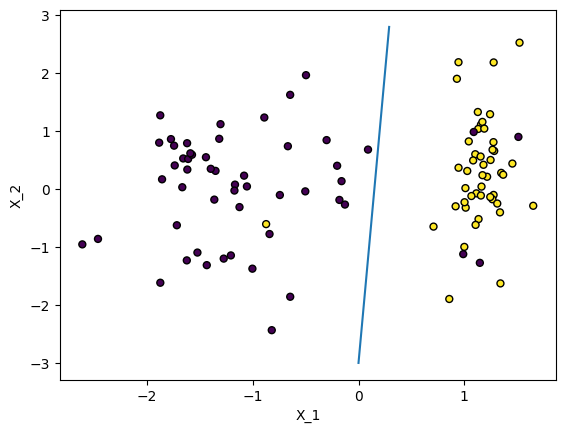

In [25]:
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.plot(x1, x2)
plt.xlabel("X_1")
plt.ylabel("X_2")

TODO: revisar signo de $\Theta^T X$ en la exponencial

Fronteras no lineal también puede ser consideradas, para ello se puede definir  $\Theta^T X$ como funcion de un polinomio, por ejemplo 

$\Theta^T X =  \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4$

\begin{equation}
h_\theta(X) =  \frac{1}{1+e^{\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4}}
\end{equation}

La frontera de desición en este caso esta determinada por:

$\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4 \geq 0$ 
para obtener un clasificador con valores de y = 1.

Para este mismo caso, supongamos que tenmos la siguiente distribución de datos, ¿Cuál es el mejor elección de parámetros $\Theta$ que permite clasificar los datos siguientes:







(np.float64(-1.12244940477901),
 np.float64(1.1839643638442499),
 np.float64(-1.2696420440360447),
 np.float64(1.185918477713659))

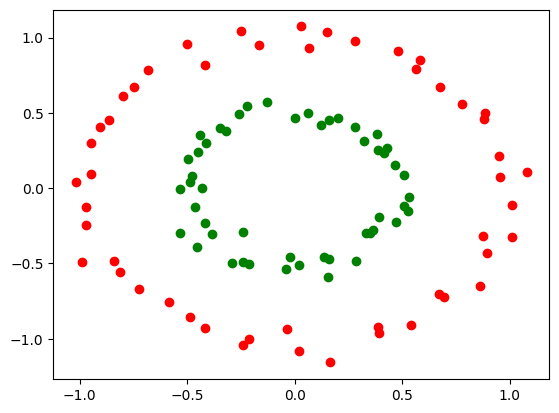

In [26]:
X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1
f, ax = plt.subplots()
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")
plt.axis("tight")

Analizando el conjunto de datos, se puede observar que la frontera es la de una circunferencia con centro en (0, 0) y radio de 0.7 aproxidamente,  asi nuestra elección de parámetros para el polinomio ejemplicado en la celda anterior ($\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4 \geq 0$ ) es: 


$\Theta^T = [0.7,0, 0, 1,1 ] $ 

Reemplando tenemos que:

$-0.7+x_1^2+x_2^2 \geq 0$

$x_1^2+x_2^2 \geq 0.7$

Text(0, 0.5, 'X_2')

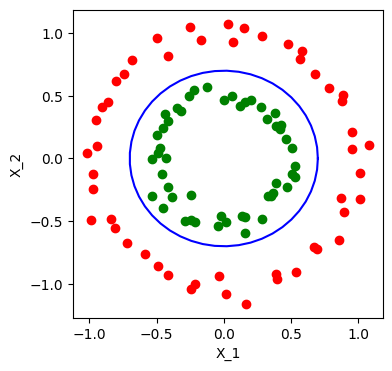

In [27]:
#Por motivos graficos transformemos la ecuación anterior parametrizada
#por theta 

alpha = np.linspace(0, 2*np.pi)
x1=0.7*np.cos(alpha)
x2=0.7*np.sin(alpha)

X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1

f, ax = plt.subplots(figsize=(4,4))
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")

plt.plot(x1, x2,"b-")
plt.axis("tight")
plt.xlabel("X_1")
plt.ylabel("X_2")

De forma general, ¿Cómo pueden ser elegidos los valores de $\Theta$?.



Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T (X)}}
\end{equation}



Para ello, podemos definir la función de coste como :


\begin{equation}
J = \left \{ 
  \begin{array}{ c l }
    -\log h(x) & \quad \textrm{if } y = 1 \\
    -\log (1-h(x))  & \quad \textrm{if } y = 0 \\
  \end{array}
\right.
\end{equation}



Resumida en la siguiente expresión:


$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

Esta función de coste permite establecer el mejor clasificadose para la regresión logistica de acuerdo a la teoría de probabilidad. Se garantiza que cuando $P(y=1|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=0|x,\theta)$, analogamente, se cumple que cuando $P(y=0|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=1|x,\theta)$. 
La metrica empleada para la regresión lineal no es recomedada en este caso, dado que la funcion de coste puede presentar múltiples minimos que dificultan la minimizacion  a través de algunas de las técnicas empleadas. Una justificación adicional para la métrica  es dada mas adelante segun la teoria de la probabilidad.

Se deja como tarea motrar que:

\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)}
\end{equation}

Para la demostración, muestre que:
- $f(z)=\frac{1}{1+e^{-z}} = f(z)(1-f(z))$
- $\frac{\partial h_{\theta}}{\partial \theta_j } = h_{\theta}(X^{(i)})(1-h_{\theta}(X^{(i)}))X_j^{(i)}$


La derivada permite aplicar el gradiente descendente para minimizar nuestra función de coste asi,  nuestro algoritmo de minimizacion permite encontrar los valores de $\theta$ despues de un conjunto determinado de itereaciones.

$\theta_j: \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$


Otros metodos de minizacion podrian ser aplicados, tales como:


[Gradiente conjugado ](https://es.wikipedia.org/wiki/M%C3%A9todo_del_gradiente_conjugado#:~:text=En%20matem%C3%A1tica%2C%20el%20m%C3%A9todo%20del,son%20sim%C3%A9tricas%20y%20definidas%20positivas.&text=Varios%20m%C3%A9todos%20del%20gradiente%20conjugado,de%20las%20ecuaciones%20no%20lineales)

[BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm)


[L-BGFS](https://en.wikipedia.org/wiki/Limited-memory_BFGS)

[Newton-Rhapson](https://en.wikipedia.org/wiki/Newton%27s_method)


# Interpretación probabilística


¿Qué tan adeacuado es la elección de $J(\theta)$  para el modelo de regresion logistica?



\begin{equation}
P(y=1|x;\theta)= h_{\theta}(X^{(i)})
\end{equation}

\begin{equation}
P(y=0|x;\theta)= 1-h_{\theta}(X^{(i)}) 
\end{equation}



\begin{equation}
P(y|x;\theta)=[h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

Asumiendo que los datos de entrenamiento son independientes:

$\cal{L}(\theta)=p(\vec{y}|x, \theta)$

\begin{equation}
\cal{L}(\theta)=\prod_{i=1}^{m} [h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

tomando el logaritmo:


\begin{equation}
\log \cal{L}(\theta)= \sum_{i=1}^{m} y \log h_{\theta}(X^{(i)}) + (1-y)(1-h_{\theta}(X^{(i)}))
\end{equation}

Los datos a considerar son los mas probables es decir que para encontrar los valores de $\theta$ que nos garantizan la maxima probabilidad es necesario maximar la función anterior. Despues de realizar los calculos se puede mostrar la ecuación dada para el gradiente de la función de coste.



En conclusión se cumple que:

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T X}}
\end{equation}



- Función de coste
$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)}
\end{equation}





# Regularización 


## Regresion Lineal
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m}\sum_{j=1}^{n} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{1}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)} 
\end{equation}



### Normal equation 
\begin{equation}
\theta=(X^TX\lambda L)^{-1} X^T y
\end{equation}

\begin{equation}
\lambda=\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\end{equation}

Las dimensiones de $[\lambda]=(\mathrm{n+1}) \times (\mathrm{n+1})$



## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m}\sum_{j=1}^{n} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{1}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)} 
\end{equation}



# Tomar el [iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) desde sklearn:

```
from sklearn import datasets

iris = datasets.load_iris()
```
- Realizar la clasifición de las tres clases  a traves de una regresión logística  y realizar multiclasicación, para ello considere lo siguiente:

Si en un dataset existen más de 2 clases, $y={0, 1, 2, 3, ...}$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.

Sea A, B, C las tres clases. Para estos valores definir:

1. Definir la clase A como la clase 0 y todas las otras B, C como la clase 1
2. Encontrar el valor $h_\theta(X) = P(y=A|x;\theta)$
3. Definir la clase B como la clase 0 y todas las otras A, C como la clase 1
4. Encontrar el valor $h_\theta(X) = P(y=B|x;\theta)$
5. Definir la clase C como la clase 0 y todas las otras A, B como la clase 1
6. Encontrar el valor $h_\theta(X) = P(y=C|x;\theta)$


Estrategia de solución. 

1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset
```
print(iris.DESCR)
```
2. Construye un dataframe: 
- los datos se pueden encontrar con la clave "data".
- los nombres de las caracteristicas con la clave: "names_features"
- La clave target nos permite indentificar el tipo de datos.


3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:
```
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ] 
cols = [col.replace(")" ,"") for col in columns_name ] 
```


4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.

5. Aplica estadística básica y construye graficas para entender el dataset. Encuentra la matriz de correlacion


6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.


7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:
```
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
```
¿Cómo se estan seprando los datos?


8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.


9. Determine  la frontera de clasificación: 
```
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0]
decision_boundary
```


10. Encontrar una gráfica de la regresión logística  con los valores de probabilidad


11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.


12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica? 




Ayudas para mejorar las metricas: 


- Normalizar cada columna respecto a su media y desviacion estandar

```
(x-mean(x))/std(x)
```

- Determinar los datos outlier 

- Construir curvas de aprendizaje

In [28]:
from sklearn import datasets

iris = datasets.load_iris()

In [29]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construir el dataframe 
# Los datos se encuentran en la clave "data"
# Los nombres de características en "feature_names"
# La clave target identifica el tipo de datos

df = pd.DataFrame(
    data=iris.data, 
    columns=iris.feature_names 
)

# Agregar la columna target
df['Target'] = iris.target

# Mostrar información del dataframe
print(df.head())
print("\nDimensiones del dataframe:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNombres de características:")
print(iris.feature_names)
print("\nClases en el dataset:", iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dimensiones del dataframe: (150, 5)

Tipos de datos:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Target                 int64
dtype: object

Nombres de características:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Clases en el dataset: ['setosa' 'versicolor' 'virginica']


In [31]:
#Ponemos la pimea letra de cada palabra en mayúscula y eliminamos los paréntesis
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ] 
cols = [col.replace(")" ,"") for col in columns_name ] 

cols

['SepalLength_cm',
 'SepalWidth_cm',
 'PetalLength_cm',
 'PetalWidth_cm',
 'Target']

In [32]:
# Asignar los nombres simplificados al dataframe
df.columns = cols

# Número de datos (filas y columnas)
print("\n1. DIMENSIONES DEL DATAFRAME:")
print(f"   - Número de muestras (filas): {df.shape[0]}")
print(f"   - Número de características (columnas): {df.shape[1]}")

# Cantidad de valores null
print("\n2. VALORES NULOS (Missing Values):")
null_counts = df.isnull().sum()
print(null_counts)
print(f"   - Total de valores null: {df.isnull().sum().sum()}")

# Tipos de datos
print("\n3. TIPOS DE DATOS:")
print(df.dtypes)

# Descripción estadística
print("\n6. DESCRIPCIÓN ESTADÍSTICA:")
print(df.describe())

# Distribución de clases (target)
print("\n7. DISTRIBUCIÓN DE LAS CLASES (Target):")
print(df['Target'].value_counts().sort_index())
print(f"   - Clase 0 (Setosa): {(df['Target'] == 0).sum()} muestras")
print(f"   - Clase 1 (Versicolor): {(df['Target'] == 1).sum()} muestras")
print(f"   - Clase 2 (Virginica): {(df['Target'] == 2).sum()} muestras")



1. DIMENSIONES DEL DATAFRAME:
   - Número de muestras (filas): 150
   - Número de características (columnas): 5

2. VALORES NULOS (Missing Values):
SepalLength_cm    0
SepalWidth_cm     0
PetalLength_cm    0
PetalWidth_cm     0
Target            0
dtype: int64
   - Total de valores null: 0

3. TIPOS DE DATOS:
SepalLength_cm    float64
SepalWidth_cm     float64
PetalLength_cm    float64
PetalWidth_cm     float64
Target              int64
dtype: object

6. DESCRIPCIÓN ESTADÍSTICA:
       SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  \
count      150.000000     150.000000      150.000000     150.000000   
mean         5.843333       3.057333        3.758000       1.199333   
std          0.828066       0.435866        1.765298       0.762238   
min          4.300000       2.000000        1.000000       0.100000   
25%          5.100000       2.800000        1.600000       0.300000   
50%          5.800000       3.000000        4.350000       1.300000   
75%          6.400


1. MATRIZ DE CORRELACIÓN:
                SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  \
SepalLength_cm        1.000000      -0.117570        0.871754       0.817941   
SepalWidth_cm        -0.117570       1.000000       -0.428440      -0.366126   
PetalLength_cm        0.871754      -0.428440        1.000000       0.962865   
PetalWidth_cm         0.817941      -0.366126        0.962865       1.000000   
Target                0.782561      -0.426658        0.949035       0.956547   

                  Target  
SepalLength_cm  0.782561  
SepalWidth_cm  -0.426658  
PetalLength_cm  0.949035  
PetalWidth_cm   0.956547  
Target          1.000000  


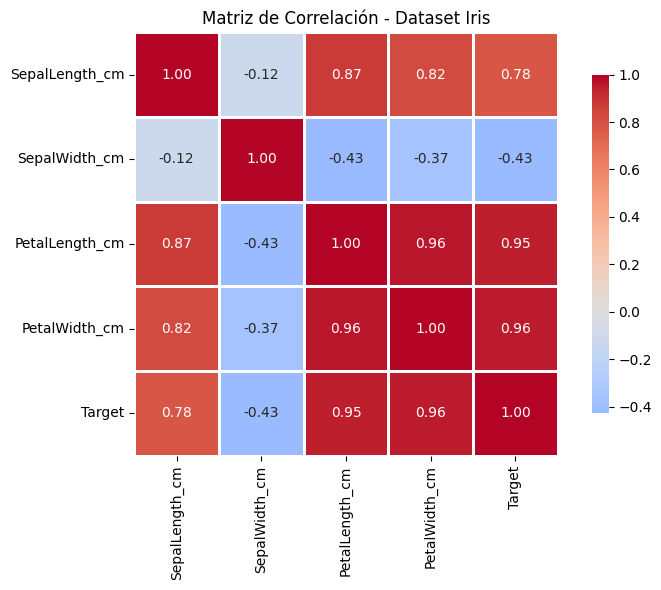


2. DISTRIBUCIÓN DE CARACTERÍSTICAS:


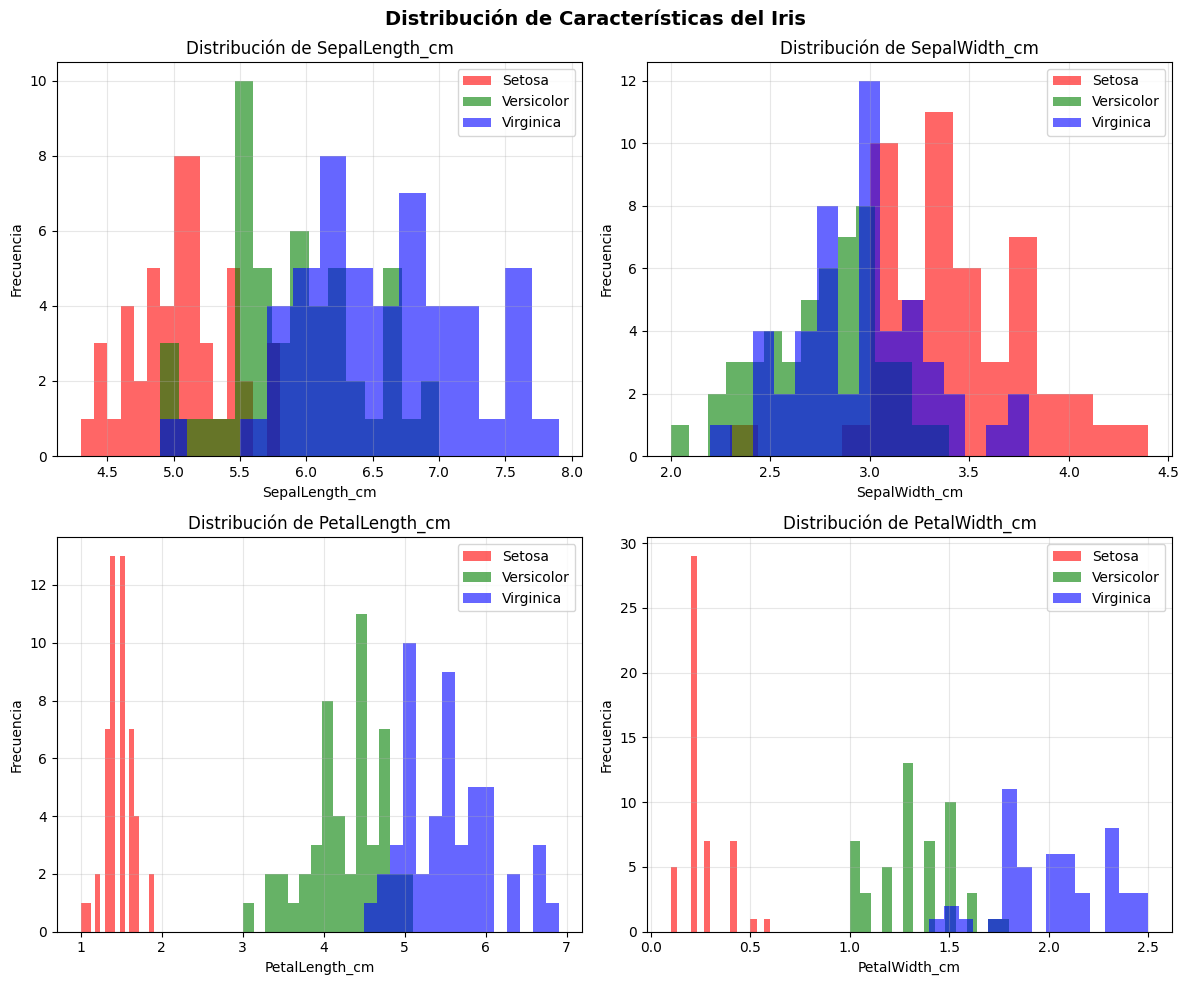


3. BOXPLOTS - DETECCIÓN DE OUTLIERS:


/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3019/691785013.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3019/691785013.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3019/691785013.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
/var/folders/wt/yys095ds4397thwy34

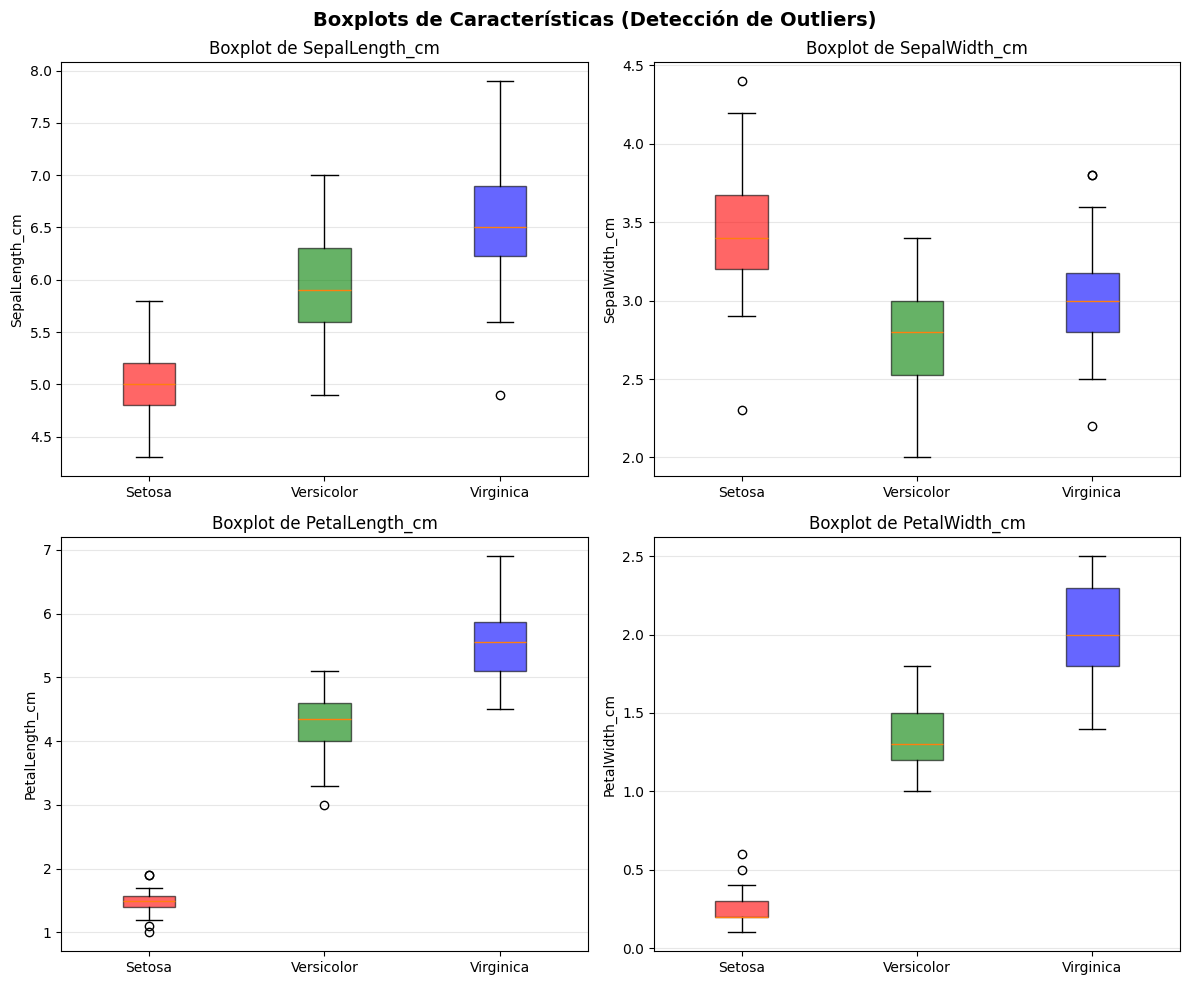


4. RELACIÓN ENTRE PARES DE CARACTERÍSTICAS:


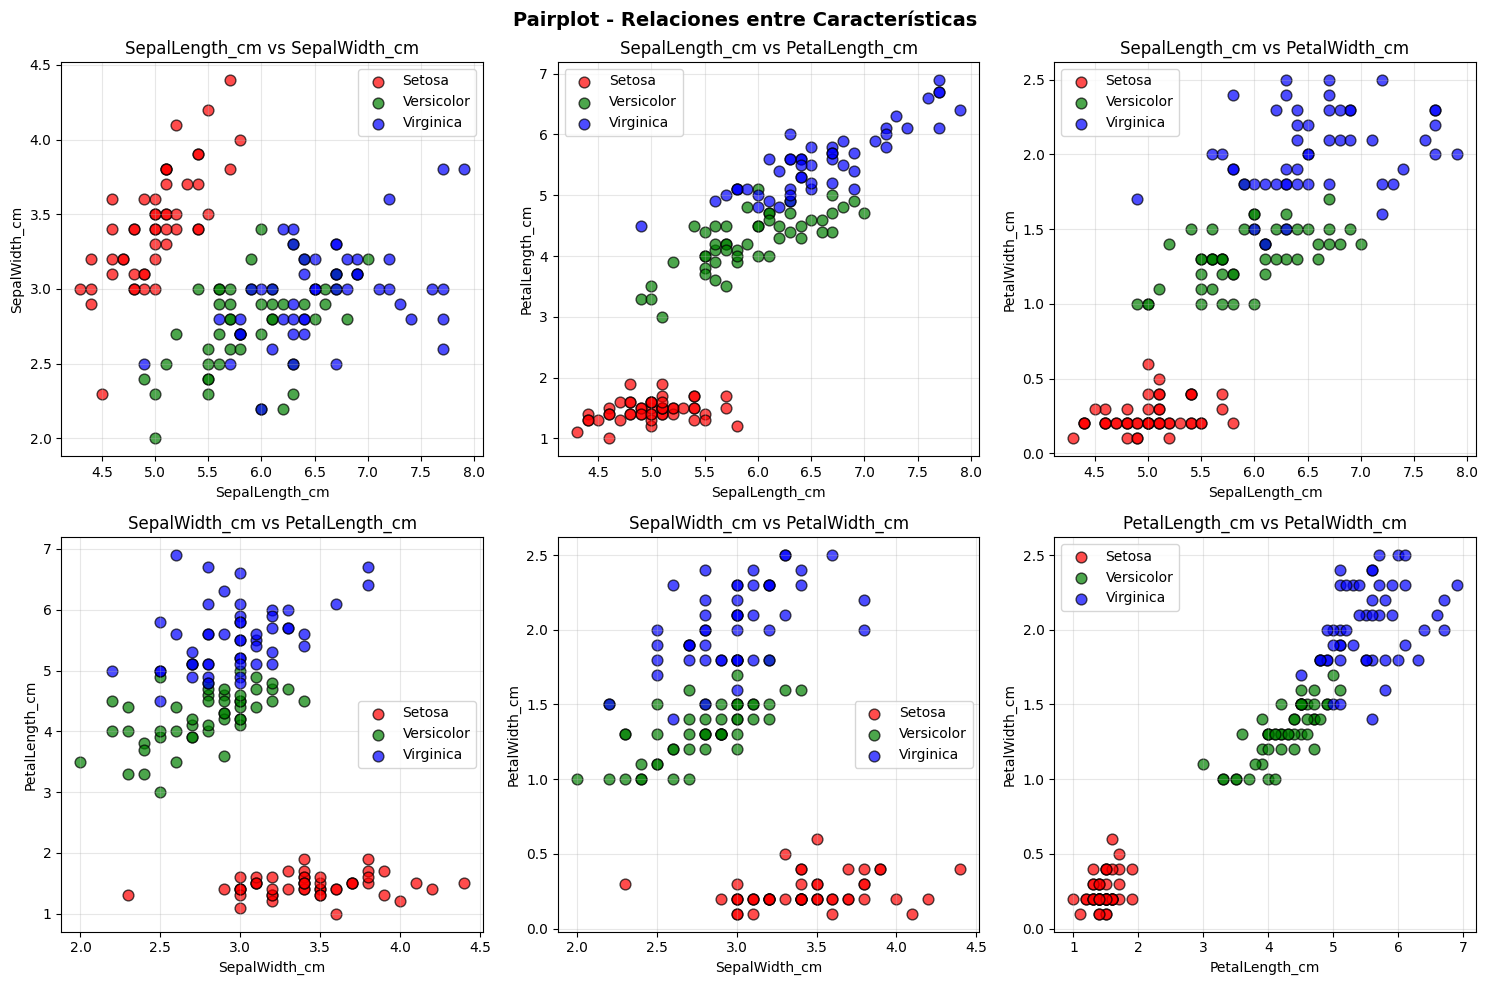


Correlaciones más altas con Target:
Target            1.000000
PetalWidth_cm     0.956547
PetalLength_cm    0.949035
SepalLength_cm    0.782561
SepalWidth_cm    -0.426658
Name: Target, dtype: float64


In [33]:
# 1. MATRIZ DE CORRELACIÓN
print("\n1. MATRIZ DE CORRELACIÓN:")
correlation_matrix = df.corr()
print(correlation_matrix)

# Visualizar la matriz de correlación con heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f', ax=ax)
plt.title('Matriz de Correlación - Dataset Iris')
plt.tight_layout()
plt.show()

# 2. HISTOGRAMAS DE LA DISTRIBUCIÓN DE CADA CARACTERÍSTICA
print("\n2. DISTRIBUCIÓN DE CARACTERÍSTICAS:")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de Características del Iris', fontsize=14, fontweight='bold')

features = [col for col in df.columns if col != 'Target']
colors_class = {0: 'red', 1: 'green', 2: 'blue'}
class_names = ['Setosa', 'Versicolor', 'Virginica']

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    for class_label in [0, 1, 2]:
        data = df[df['Target'] == class_label][feature]
        ax.hist(data, label=class_names[class_label], alpha=0.6, 
                color=colors_class[class_label], bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. BOXPLOTS PARA DETECTAR OUTLIERS
print("\n3. BOXPLOTS - DETECCIÓN DE OUTLIERS:")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Boxplots de Características (Detección de Outliers)', fontsize=14, fontweight='bold')

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    data_by_class = [df[df['Target'] == i][feature] for i in [0, 1, 2]]
    bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
    
    # Colorear los boxplots
    for patch, color in zip(bp['boxes'], ['red', 'green', 'blue']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_ylabel(feature)
    ax.set_title(f'Boxplot de {feature}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. SCATTERPLOT DE PARES DE CARACTERÍSTICAS
print("\n4. RELACIÓN ENTRE PARES DE CARACTERÍSTICAS:")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Pairplot - Relaciones entre Características', fontsize=14, fontweight='bold')

feature_pairs = [
    ('SepalLength_cm', 'SepalWidth_cm'),
    ('SepalLength_cm', 'PetalLength_cm'),
    ('SepalLength_cm', 'PetalWidth_cm'),
    ('SepalWidth_cm', 'PetalLength_cm'),
    ('SepalWidth_cm', 'PetalWidth_cm'),
    ('PetalLength_cm', 'PetalWidth_cm')
]

for ax, (feat1, feat2) in zip(axes.flat, feature_pairs):
    for class_label in [0, 1, 2]:
        mask = df['Target'] == class_label
        ax.scatter(df[mask][feat1], df[mask][feat2], 
                  label=class_names[class_label], 
                  color=colors_class[class_label], alpha=0.7, s=60, edgecolors='k')
    
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    ax.set_title(f'{feat1} vs {feat2}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nCorrelaciones más altas con Target:")
target_corr = correlation_matrix['Target'].sort_values(ascending=False)
print(target_corr)


Quitaremos los valores que quedan fuera de los outliers para trabajar con un data set limpio 

In [34]:

def remove_outliers_by_class(dataframe):
    """
    Elimina outliers por CLASE usando el método IQR
    Esto es más preciso porque calcula los límites para cada clase por separado
    """
    df_clean = dataframe.copy()
    features = [col for col in df_clean.columns if col != 'Target']
    
    total_outliers = 0
    outlier_indices = set()
    
    # Para cada clase
    for class_label in [0, 1, 2]:
        class_name = ['Setosa', 'Versicolor', 'Virginica'][class_label]
        
        class_mask = df_clean['Target'] == class_label
        class_data = df_clean[class_mask]
        
        class_outliers = 0
        
        # Para cada característica
        for feature in features:
            Q1 = class_data[feature].quantile(0.25)
            Q3 = class_data[feature].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Encontrar outliers para esta clase y característica
            outliers_mask = (class_data[feature] < lower_bound) | (class_data[feature] > upper_bound)
            outliers_indices = class_data[outliers_mask].index
            
            if len(outliers_indices) > 0:
                outlier_indices.update(outliers_indices)
                class_outliers += len(outliers_indices)
        
        if class_outliers > 0:
            total_outliers += class_outliers
    
    # Eliminar todas las filas con outliers
    df_clean = df_clean.drop(list(outlier_indices))
    
    return df_clean, total_outliers, len(outlier_indices)

# Aplicar la función
df, total_outliers, n_indices = remove_outliers_by_class(df)

# Resetear el índice
df = df.reset_index(drop=True)

Separamos los datos en train 80% y test 20%


In [35]:
from sklearn.model_selection import StratifiedShuffleSplit

for class_label in [0, 1, 2]:
    count = (df['Target'] == class_label).sum()
    class_names_tmp = ['Setosa', 'Versicolor', 'Virginica']
    pct = (count / df.shape[0]) * 100


# Aplicar StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['Target']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]


print("RESULTADOS DE LA SEPARACIÓN:")

print(f"\nConjunto de ENTRENAMIENTO:")
print(f"  Muestras: {strat_train_set.shape[0]} ({100*len(train_index)/df.shape[0]:.1f}%)")
print(f"  Distribución de clases:")
for class_label in [0, 1, 2]:
    count = (strat_train_set['Target'] == class_label).sum()
    class_names_tmp = ['Setosa', 'Versicolor', 'Virginica']
    pct = (count / strat_train_set.shape[0]) * 100
    print(f"    Clase {class_label} ({class_names_tmp[class_label]:12s}): {count:3d} muestras ({pct:5.1f}%)")

print(f"\nConjunto de PRUEBA (Test):")
print(f"  Muestras: {strat_test_set.shape[0]} ({100*len(test_index)/df.shape[0]:.1f}%)")
print(f"  Distribución de clases:")
for class_label in [0, 1, 2]:
    count = (strat_test_set['Target'] == class_label).sum()
    class_names_tmp = ['Setosa', 'Versicolor', 'Virginica']
    pct = (count / strat_test_set.shape[0]) * 100
    print(f"    Clase {class_label} ({class_names_tmp[class_label]:12s}): {count:3d} muestras ({pct:5.1f}%)")


# Separar características (X) y target (y)
X_train = strat_train_set.drop(['Target'], axis=1)
y_train = strat_train_set['Target']

X_test = strat_test_set.drop(['Target'], axis=1)
y_test = strat_test_set['Target']


RESULTADOS DE LA SEPARACIÓN:

Conjunto de ENTRENAMIENTO:
  Muestras: 109 (79.6%)
  Distribución de clases:
    Clase 0 (Setosa      ):  33 muestras ( 30.3%)
    Clase 1 (Versicolor  ):  39 muestras ( 35.8%)
    Clase 2 (Virginica   ):  37 muestras ( 33.9%)

Conjunto de PRUEBA (Test):
  Muestras: 28 (20.4%)
  Distribución de clases:
    Clase 0 (Setosa      ):   9 muestras ( 32.1%)
    Clase 1 (Versicolor  ):  10 muestras ( 35.7%)
    Clase 2 (Virginica   ):   9 muestras ( 32.1%)


Para clasificar Setosa vs No-Setosa, se necesita crear un clasificador binario. 

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# 1. NORMALIZAR LOS DATOS (importante para regresión logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. CREAR CLASIFICACIÓN BINARIA: Setosa (0) vs No-Setosa (1)
y_train_binary = (y_train == 0).astype(int)  # 1 si es Setosa, 0 si no es Setosa
y_test_binary = (y_test == 0).astype(int)

print("Distribución de clases binarias (Train):")
print(f"  Setosa (0): {(y_train_binary == 0).sum()} muestras")
print(f"  No-Setosa (1): {(y_train_binary == 1).sum()} muestras")

# 3. CREAR Y ENTRENAR EL MODELO DE REGRESIÓN LOGÍSTICA
log_reg = LogisticRegression(
    max_iter=1000,           # Número máximo de iteraciones
    random_state=42,         # Para reproducibilidad
    solver='lbfgs',          # Método de optimización
    C=1.0                    # Parámetro de regularización inversa (menor C = más regularización)
)

log_reg.fit(X_train_scaled, y_train_binary)

print("\n" + "="*60)
print("MODELO DE REGRESIÓN LOGÍSTICA ENTRENADO")
print("="*60)

# 4. REALIZAR PREDICCIONES
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Obtener probabilidades
y_train_proba = log_reg.predict_proba(X_train_scaled)
y_test_proba = log_reg.predict_proba(X_test_scaled)

# 5. EVALUAR EL MODELO
print("\nMÉTRICAS DE DESEMPEÑO:")
print("\nConjunto de ENTRENAMIENTO:")
print(f"  Accuracy:  {accuracy_score(y_train_binary, y_train_pred):.4f}")
print(f"  Precision: {precision_score(y_train_binary, y_train_pred):.4f}")
print(f"  Recall:    {recall_score(y_train_binary, y_train_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_train_binary, y_train_pred):.4f}")

print("\nConjunto de PRUEBA (Test):")
print(f"  Accuracy:  {accuracy_score(y_test_binary, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test_binary, y_test_pred):.4f}")
print(f"  Recall:    {recall_score(y_test_binary, y_test_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test_binary, y_test_pred):.4f}")

# 6. MATRIZ DE CONFUSIÓN
print("\nMATRIZ DE CONFUSIÓN (Test):")
cm = confusion_matrix(y_test_binary, y_test_pred)
print(cm)
print("\nReporte de clasificación:")
print(classification_report(y_test_binary, y_test_pred, target_names=['Setosa', 'No-Setosa']))

# 7. PARÁMETROS DEL MODELO
print("\nPARÁMETROS DEL MODELO:")
print(f"  Coeficientes (θ): {log_reg.coef_[0]}")
print(f"  Intercepto (θ0): {log_reg.intercept_[0]}")


Distribución de clases binarias (Train):
  Setosa (0): 76 muestras
  No-Setosa (1): 33 muestras

MODELO DE REGRESIÓN LOGÍSTICA ENTRENADO

MÉTRICAS DE DESEMPEÑO:

Conjunto de ENTRENAMIENTO:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Conjunto de PRUEBA (Test):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

MATRIZ DE CONFUSIÓN (Test):
[[19  0]
 [ 0  9]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
   No-Setosa       1.00      1.00      1.00         9

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28


PARÁMETROS DEL MODELO:
  Coeficientes (θ): [-0.96728285  1.18677542 -1.55768783 -1.45173246]
  Intercepto (θ0): -2.6605805919728773


In [39]:
# 9: DETERMINAR LA FRONTERA DE CLASIFICACIÓN


print("\n" + "="*60)
print("FRONTERA DE CLASIFICACIÓN")
print("="*60)

# Para visualizar la frontera, usamos dos características principales
# PetalLength_cm y PetalWidth_cm (las más correlacionadas con Target)

# Crear una malla de puntos para visualizar la frontera
h = 0.02  # Tamaño del paso en la malla
x_min, x_max = X_test_scaled[:, 2].min() - 1, X_test_scaled[:, 2].max() + 1
y_min, y_max = X_test_scaled[:, 3].min() - 1, X_test_scaled[:, 3].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Crear puntos con todas las características (usando media para las otras)
X_mesh = np.c_[np.full(xx.ravel().shape, X_test_scaled[:, 0].mean()),
               np.full(xx.ravel().shape, X_test_scaled[:, 1].mean()),
               xx.ravel(), 
               yy.ravel()]

Z = log_reg.predict(X_mesh)
Z = Z.reshape(xx.shape)

# Encontrar el valor de decisión exacto
Z_proba = log_reg.predict_proba(X_mesh)[:, 1]
Z_proba = Z_proba.reshape(xx.shape)

print(f"Frontera de decisión identificada")
print(f"  Rango X (PetalLength): [{x_min:.2f}, {x_max:.2f}]")
print(f"  Rango Y (PetalWidth): [{y_min:.2f}, {y_max:.2f}]")




FRONTERA DE CLASIFICACIÓN
Frontera de decisión identificada
  Rango X (PetalLength): [-2.48, 2.42]
  Rango Y (PetalWidth): [-2.38, 2.68]



GRÁFICA DE REGRESIÓN LOGÍSTICA


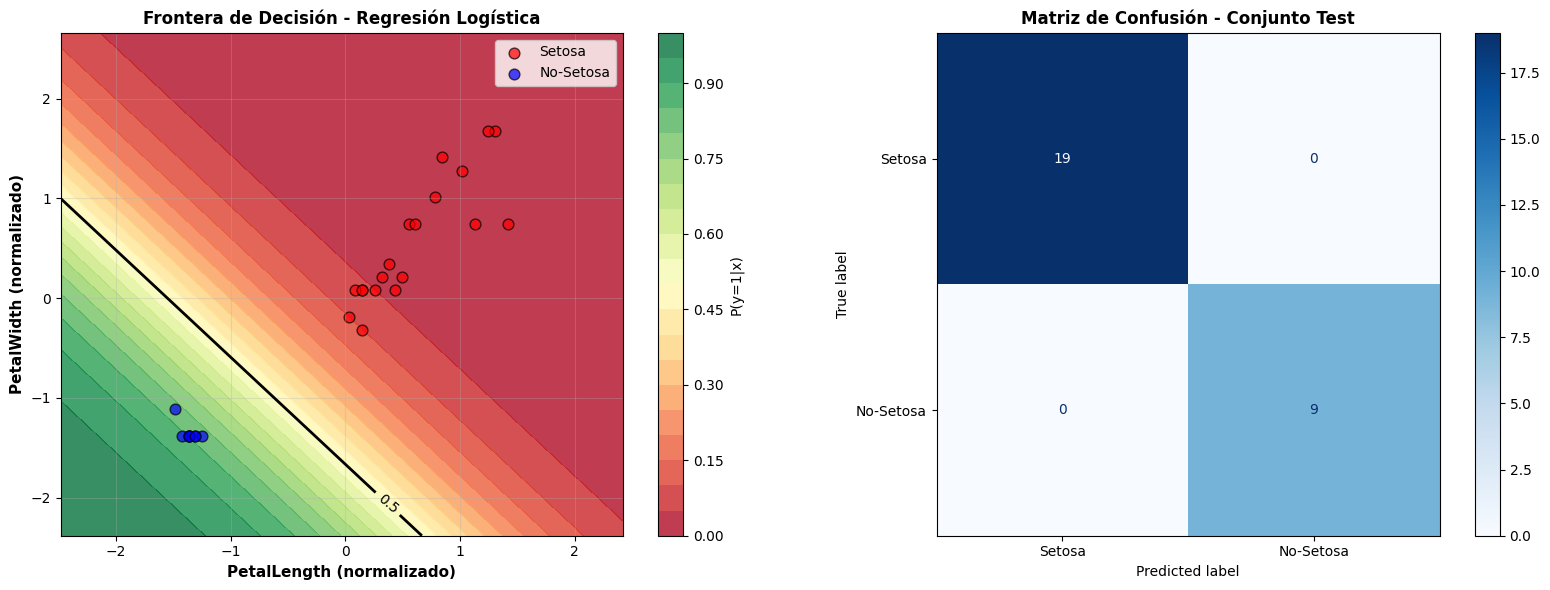

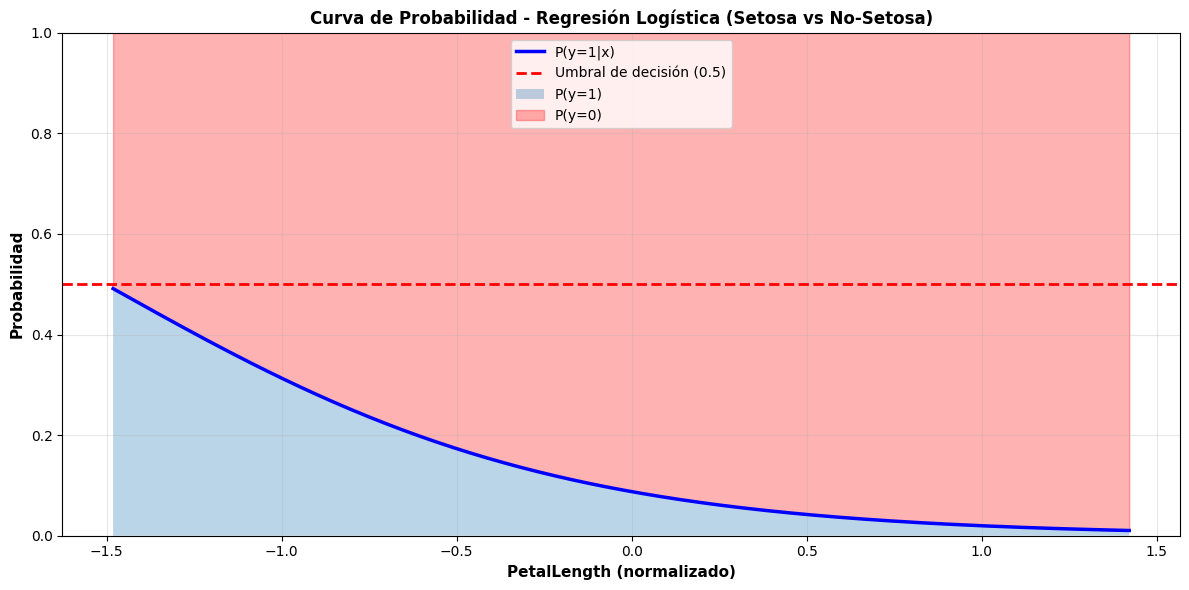

In [41]:

# 10 GRÁFICA DE REGRESIÓN LOGÍSTICA CON PROBABILIDADES
print("\n" + "="*60)
print("GRÁFICA DE REGRESIÓN LOGÍSTICA")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Frontera de decisión con contornos
ax = axes[0]
contour = ax.contourf(xx, yy, Z_proba, levels=20, cmap='RdYlGn', alpha=0.8)
contour_lines = ax.contour(xx, yy, Z_proba, levels=[0.5], colors='black', linewidths=2)
ax.clabel(contour_lines, inline=True, fontsize=10)

# Plotear los datos de test
for class_label in [0, 1]:
    mask = y_test_binary == class_label
    ax.scatter(X_test_scaled[mask, 2], X_test_scaled[mask, 3],
              c=['red', 'blue'][class_label], 
              label=['Setosa', 'No-Setosa'][class_label],
              edgecolors='k', s=60, alpha=0.7)

ax.set_xlabel('PetalLength (normalizado)', fontsize=11, fontweight='bold')
ax.set_ylabel('PetalWidth (normalizado)', fontsize=11, fontweight='bold')
ax.set_title('Frontera de Decisión - Regresión Logística', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('P(y=1|x)', fontsize=10)

# Gráfica 2: Matriz de confusión visualizada
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                    display_labels=['Setosa', 'No-Setosa'])
cm_display.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Matriz de Confusión - Conjunto Test', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Gráfica 3: Curva de probabilidad
fig, ax = plt.subplots(figsize=(12, 6))

# Crear rango de valores para una característica mientras mantenemos otras constantes
feature_range = np.linspace(X_test_scaled[:, 2].min(), X_test_scaled[:, 2].max(), 300)
X_plot = np.c_[np.full(feature_range.shape, X_test_scaled[:, 0].mean()),
               np.full(feature_range.shape, X_test_scaled[:, 1].mean()),
               feature_range,
               np.full(feature_range.shape, X_test_scaled[:, 3].mean())]

y_proba_plot = log_reg.predict_proba(X_plot)[:, 1]

ax.plot(feature_range, y_proba_plot, 'b-', linewidth=2.5, label='P(y=1|x)')
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Umbral de decisión (0.5)')
ax.fill_between(feature_range, 0, y_proba_plot, alpha=0.3, label='P(y=1)')
ax.fill_between(feature_range, y_proba_plot, 1, alpha=0.3, color='red', label='P(y=0)')

ax.set_xlabel('PetalLength (normalizado)', fontsize=11, fontweight='bold')
ax.set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
ax.set_title('Curva de Probabilidad - Regresión Logística (Setosa vs No-Setosa)', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()




In [49]:
print("INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("""
Estructura:
                Predicho
                Negativo  Positivo
Real Negativo    TN        FP
     Positivo    FN        TP

Donde:
├─ TN (Verdaderos Negativos): Setosas identificadas correctamente
├─ FP (Falsos Positivos): No-Setosas clasificadas como Setosa (error Tipo I)
├─ FN (Falsos Negativos): No-Setosas clasificadas como Setosa (error Tipo II)
└─ TP (Verdaderos Positivos): No-Setosas identificadas correctamente
      
De esta manera podemos ver que las clasificaciones se hicieron de la manera adecuada""")



INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:

Estructura:
                Predicho
                Negativo  Positivo
Real Negativo    TN        FP
     Positivo    FN        TP

Donde:
├─ TN (Verdaderos Negativos): Setosas identificadas correctamente
├─ FP (Falsos Positivos): No-Setosas clasificadas como Setosa (error Tipo I)
├─ FN (Falsos Negativos): No-Setosas clasificadas como Setosa (error Tipo II)
└─ TP (Verdaderos Positivos): No-Setosas identificadas correctamente

De esta manera podemos ver que las clasificaciones se hicieron de la manera adecuada



PASO 11: MULTICLASIFICADOR (SOFTMAX REGRESSION)

MÉTRICAS DEL MULTICLASIFICADOR:

Conjunto de ENTRENAMIENTO:
  Accuracy: 0.9633

Conjunto de PRUEBA (Test):
  Accuracy: 1.0000

Reporte de clasificación (Test):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         9
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00         9

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



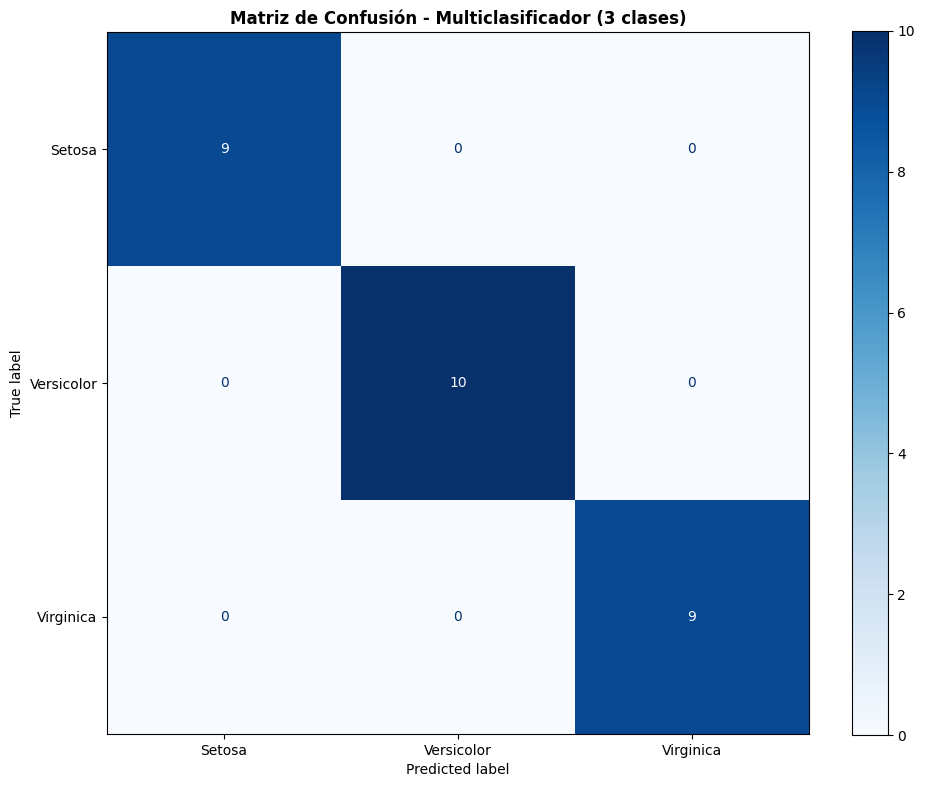


PARÁMETROS DEL MULTICLASIFICADOR:
  Número de clases: 3
  Clases: [0 1 2]
  Forma de coeficientes: (3, 4)
  Interceptos: [-0.46809496  1.94895782 -1.48086285]


In [51]:
# 11 MULTICLASIFICADOR (SOFTMAX REGRESSION)

print("\n" + "="*60)
print("PASO 11: MULTICLASIFICADOR (SOFTMAX REGRESSION)")
print("="*60)

# Crear un multiclasificador usando softmax regression
# En sklearn, LogisticRegression usa automáticamente multinomial (softmax) 
# cuando hay más de 2 clases
multi_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'  # Funciona bien con softmax automáticamente
)

multi_clf.fit(X_train_scaled, y_train)

# Realizar predicciones
y_train_pred_multi = multi_clf.predict(X_train_scaled)
y_test_pred_multi = multi_clf.predict(X_test_scaled)

# Obtener probabilidades para todas las clases
y_train_proba_multi = multi_clf.predict_proba(X_train_scaled)
y_test_proba_multi = multi_clf.predict_proba(X_test_scaled)

# Evaluar el multiclasificador
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nMÉTRICAS DEL MULTICLASIFICADOR:")
print("\nConjunto de ENTRENAMIENTO:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_multi):.4f}")

print("\nConjunto de PRUEBA (Test):")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_multi):.4f}")

print("\nReporte de clasificación (Test):")
print(classification_report(y_test, y_test_pred_multi, 
                           target_names=['Setosa', 'Versicolor', 'Virginica']))

# Matriz de confusión para multiclasificador
cm_multi = confusion_matrix(y_test, y_test_pred_multi)


# Visualizar matriz de confusión multiclase
fig, ax = plt.subplots(figsize=(10, 8))
cm_display_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi,
                                          display_labels=['Setosa', 'Versicolor', 'Virginica'])
cm_display_multi.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión - Multiclasificador (3 clases)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar información adicional del modelo
print("\nPARÁMETROS DEL MULTICLASIFICADOR:")
print(f"  Número de clases: {len(multi_clf.classes_)}")
print(f"  Clases: {multi_clf.classes_}")
print(f"  Forma de coeficientes: {multi_clf.coef_.shape}")
print(f"  Interceptos: {multi_clf.intercept_}")



12 PREDICCIÓN PARA MUESTRA NUEVA

Muestra nueva: [4.9 5.  1.8 0.3]
Características: [SepalLength, SepalWidth, PetalLength, PetalWidth]

PREDICCIÓN:
  Clase predicha: Setosa (Clase 0)

PROBABILIDADES POR CLASE:
  P(Setosa      ) = 0.9999 (99.99%)
  P(Versicolor  ) = 0.0001 ( 0.01%)
  P(Virginica   ) = 0.0000 ( 0.00%)

Confianza de la predicción: 0.9999 (99.99%)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


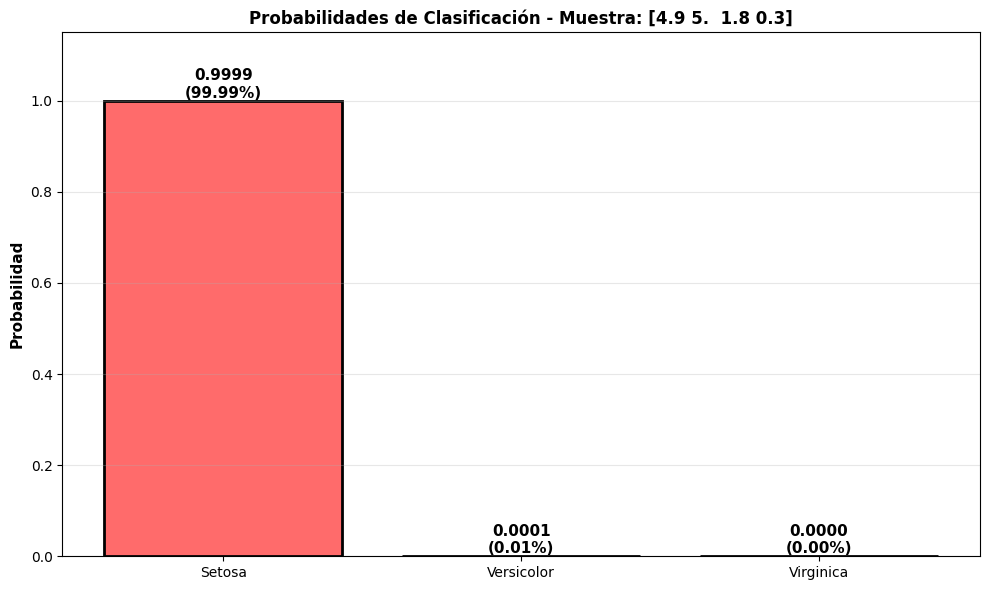

In [53]:

#  PREDICCIÓN PARA NUEVA MUESTRA


print("\n" + "="*60)
print("12 PREDICCIÓN PARA MUESTRA NUEVA")
print("="*60)

# Muestra nueva: [4.9, 5.0, 1.8, 0.3]
X_new_sample = np.array([[4.9, 5.0, 1.8, 0.3]])

# Normalizar la muestra usando el scaler del entrenamiento
X_new_sample_scaled = scaler.transform(X_new_sample)

# Realizar predicción (clase)
y_new_pred = multi_clf.predict(X_new_sample_scaled)[0]

# Obtener probabilidades
y_new_proba = multi_clf.predict_proba(X_new_sample_scaled)[0]

class_names_multi = ['Setosa', 'Versicolor', 'Virginica']

print(f"\nMuestra nueva: {X_new_sample[0]}")
print(f"Características: [SepalLength, SepalWidth, PetalLength, PetalWidth]")

print(f"\nPREDICCIÓN:")
print(f"  Clase predicha: {class_names_multi[y_new_pred]} (Clase {y_new_pred})")

print(f"\nPROBABILIDADES POR CLASE:")
for i, class_name in enumerate(class_names_multi):
    print(f"  P({class_name:12s}) = {y_new_proba[i]:.4f} ({y_new_proba[i]*100:5.2f}%)")

print(f"\nConfianza de la predicción: {y_new_proba.max():.4f} ({y_new_proba.max()*100:.2f}%)")

# Mostrar la predicción de forma visual
fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(class_names_multi, y_new_proba, color=colors_bar, edgecolor='black', linewidth=2)

# Añadir valores en las barras
for bar, prob in zip(bars, y_new_proba):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{prob:.4f}\n({prob*100:.2f}%)',
           ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
ax.set_title(f'Probabilidades de Clasificación - Muestra: {X_new_sample[0]}', 
             fontsize=12, fontweight='bold')
ax.set_ylim([0, max(y_new_proba) * 1.15])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# [SOFTMAX REGRESION](https://es.wikipedia.org/wiki/Funci%C3%B3n_SoftMax)


La elección anterior es conocida com softmax regresión, que permite definir un conjunto de probabilidades asociadas a un conjunto de clases. Al definir el maximo valor de la probabilidad dado un conjunto de inputs se tiene el objeto que predice el modelo, una forma de hacer una implementación rapida es mostrada a continuación.

[Referencias]  [Hand on Machine learning](https://github.com/ageron/handson-ml/blob/master/04_training_linear_models.ipynb)


# Reto, no es obligatorio.

### Clasificación de pulsar.

Para el siguiente  dataset descrito en el este enlace [pulsar](https://archive.ics.uci.edu/ml/datasets/HTRU2)  , construir un clasificador logístico, para ello, deberá primera entender las caracteristicas del problema y seguidamente estudiar el comportamiento de la clasificacion realizada.


1. Dividir los datos en train and test
2. Entrenar el algoritmo.
3. Analizar las curvas de aprendizaje.
4. Realizar Predicciones
5. Aplicar regularización.


Referencias

[1] http://cs229.stanford.edu/syllabus.html

[2] https://www.coursera.org/learn/machine-learning. Week 3.

[3] https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py


[4]https://scikit-learn.org/stable/datasets/toy_dataset.html